# M01. Weather Factors

In [1]:
from U01Imports import *
from U02Functions import *
from U03Classes import *
from U04Datasets import *
from U05Models import *

Using device: cuda


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Settings

In [3]:
# Training window
min_training_date = '20180101'
max_training_date = '20251230'

# Testing (out-of-sample) window — bounded, used for all OOS wOBA evaluation
min_testing_date  = '20260101'
max_testing_date  = '20260630'

### Data

##### Plate Appearances

In [4]:
start_year, end_year = 2015, 2026  # Years to include in the batted ball dataset

In [5]:
df = merge_datasets(start_year, end_year)
df = create_events(df)

Keep relevant columns and PAs

In [6]:
df = df[['eventsModel', 'description', 'batter', 'batterName', 'batSide', 'pitcher', 'pitcherName', 'pitchHand', 'gamePk', 'weather', 'wind', 'venue_id', 'venue', 'date', 'game_type', 'hc_x', 'hc_y', 'hit_distance_sc', 'launch_speed', 'launch_angle', 'launch_speed_angle', 'estimated_woba_using_speedangle']]

In [7]:
df = df[df['eventsModel'] != "Cut"]

In [8]:
df['hit_distance_sc'].notna().sum()

np.int64(1306537)

##### Open Meteo

In [9]:
open_meteo_column_list = ['game_id', 'year', 'date', 'venue_id', 'venue_name', 'location.defaultCoordinates.latitude', 'location.defaultCoordinates.longitude',
                          'fieldInfo.leftLine', 'fieldInfo.center', 'fieldInfo.rightLine', 'fieldInfo.leftCenter', 'fieldInfo.rightCenter',
                          'location.elevation', 'location.azimuthAngle', 'fieldInfo.roofType', 'active',
                          'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'surface_pressure',
                          'wind_speed_10m', 'wind_direction_10m', 'weather_code', 'precipitation_probability']

weather_df = pd.concat(map(pd.read_csv, glob.glob(os.path.join(baseball_path, "A06. Weather", "1. Open Meteo", "*.csv"))), ignore_index=True)[open_meteo_column_list]

### Merge

##### MLB Stats API with Open Meteo

In [10]:
weather_dataset = df.merge(weather_df.drop(columns=['year', 'venue_id', 'date']), left_on=['gamePk'], right_on=['game_id'], how='inner')

### Roof Status

Determine temperatures at which roofs are usually closed by venue. Only used in B02WFX (daily weather) because we have actual closure info available in historic data.

In [11]:
# Define temperature bins from 50 to 95 in 5-degree increments
bins = list(range(50, 100, 5))  # 50, 55, 60, ..., 95
labels = [f'{b}-{b+5}' for b in bins[:-1]]  # '50-55', '55-60', ...

# Bin the temperatures
weather_dataset['temp_bin'] = pd.cut(weather_dataset['temperature_2m'], bins=bins, labels=labels, right=False)

# Group by venue_id and temp_bin
roof_pivot = (weather_dataset.groupby(['venue_id', 'temp_bin'])['weather']
    .apply(lambda x: x.str.contains('Roof Closed', case=False, na=False).mean() * 100)
    .reset_index(name='percent_roof_closed')
    .pivot(index='venue_id', columns='temp_bin', values='percent_roof_closed')
    .fillna(0))

# Only show venues with any meaningful roof closure (rowsum > 1)
roof_pivot[roof_pivot.sum(axis=1) > 1]

temp_bin,50-55,55-60,60-65,65-70,70-75,75-80,80-85,85-90,90-95
venue_id,,,,,,,,,
12,0.000000,0.000000,0.000000,0.000000,0.000000,1.035276,0.747817,2.502141,0.000000
14,97.859054,75.505561,45.587762,29.741338,18.259978,14.883891,16.897570,33.575054,75.261324
15,100.000000,100.000000,0.000000,16.891892,25.648556,29.713638,42.012976,37.217325,61.893380
32,100.000000,86.745034,56.372788,37.409645,22.232418,16.285888,12.928669,6.703015,18.497653
680,37.973787,28.804089,10.248609,1.087647,3.700581,1.904637,0.000000,0.000000,0.000000
2392,53.191489,0.000000,53.054662,74.600188,78.831975,81.023729,96.199583,99.578947,100.000000
4169,0.000000,0.000000,0.000000,100.000000,70.846395,68.909043,88.387874,94.821655,100.000000
5325,0.000000,100.000000,87.304348,46.169221,66.714906,76.012050,79.924167,92.845131,98.623636


### Wind Push

In [12]:
def add_wind_push_features(df):
    """
    Adds spray-angle-relative wind features to weather_dataset,
    building the wind vector directly from wind_direction_10m,
    wind_speed_10m, and location.azimuthAngle.
    """

    # --- Spray angle (degrees, 0 = dead center) ---
    df['spray_angle'] = np.arctan(
        (df['hc_x'] - 125.42) / (198.27 - df['hc_y'])
    ) * 180 / np.pi * 0.75
    spray_rad = np.radians(df['spray_angle'])

    df['ball_dir_x'] = np.sin(spray_rad)
    df['ball_dir_y'] = np.cos(spray_rad)

    # --- Raw wind vector in North/East compass frame ---
    # wind_direction_10m = direction wind is blowing FROM (meteorological convention)
    # flip 180 to get direction wind is blowing TOWARD
    blowing_to_rad = np.radians((df['wind_direction_10m'] + 180) % 360)

    raw_north = df['wind_speed_10m'] * np.cos(blowing_to_rad)
    raw_east  = df['wind_speed_10m'] * np.sin(blowing_to_rad)

    # --- Rotate into park frame using azimuthAngle ---
    # azimuthAngle = compass bearing from home plate toward CF (deg, clockwise from N)
    theta = np.radians(df['location.azimuthAngle'])

    df['meteo_y_vect'] = raw_east * np.sin(theta) + raw_north * np.cos(theta)  # toward CF
    df['meteo_x_vect'] = raw_east * np.cos(theta) - raw_north * np.sin(theta)  # left-right

    # --- Wind push along ball flight path ---
    df['wind_push'] = (
        df['meteo_x_vect'] * df['ball_dir_x'] +
        df['meteo_y_vect'] * df['ball_dir_y']
    )

    # --- Crosswind component (perpendicular) ---
    df['wind_cross'] = (
        df['meteo_x_vect'] * df['ball_dir_y'] -
        df['meteo_y_vect'] * df['ball_dir_x']
    )

    return df

In [13]:
weather_dataset = add_wind_push_features(weather_dataset)

### Weather Corrections

Seattle Correction: T-Mobile has a retractable roof but it's open on the sides, so most weather is unaffected.

In [14]:
weather_dataset.loc[weather_dataset['venue_id'].astype(str) == '680', 'fieldInfo.roofType'] = 'Open'

Identify games in domes/with roofs

In [15]:
mask = (weather_dataset['weather'].str.contains('Roof|Dome', case=False, na=False) |
        (weather_dataset['venue_id'] == '12'))  # Manual Tropicana inclusion to account for raw data issues

Replace those with uneventful weather and no wind

In [16]:
weather_dataset.loc[mask, 'temperature_2m'] = 70
weather_dataset.loc[mask, 'meteo_x_vect'] = 0
weather_dataset.loc[mask, 'meteo_y_vect'] = 0
weather_dataset.loc[mask, 'relative_humidity_2m'] = 60
weather_dataset.loc[mask, 'dew_point_2m'] = 57
weather_dataset.loc[mask, 'wind_push'] = 0
weather_dataset.loc[mask, 'wind_cross'] = 0

### Carry

In [17]:
# --- Rolling league-wide carry signal (well-struck fly balls, trailing 365 days) ---
def add_rolling_carry_feature(df, min_angle=28, max_angle=32, min_speed=100, window_days=365):
    """
    Adds a league-wide trailing rolling average of hit_distance_sc for
    well-struck balls (launch_angle in [min_angle, max_angle], launch_speed >= min_speed).
    Intended as a proxy for ball/drag-coefficient drift over time.

    Leakage-safe: each date's value excludes that date's own qualifying balls.
    """
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    qualifying = df[
        (df['launch_angle'] >= min_angle) & (df['launch_angle'] <= max_angle) &
        (df['launch_speed'] >= min_speed)
    ]

    daily = (
        qualifying.groupby('date')['hit_distance_sc']
        .agg(sum_dist='sum', cnt='count')
        .sort_index()
    )

    # Rolling 365-calendar-day sum/count (inclusive of the day itself, for now)
    rolling_sum = daily['sum_dist'].rolling(f'{window_days}D').sum()
    rolling_cnt = daily['cnt'].rolling(f'{window_days}D').sum()

    # Subtract off the current day's own contribution to avoid leakage
    excl_sum = rolling_sum - daily['sum_dist']
    excl_cnt = rolling_cnt - daily['cnt']

    daily['rolling_carry_365d'] = excl_sum / excl_cnt  # NaN where excl_cnt == 0

    df = df.merge(daily[['rolling_carry_365d']], left_on='date', right_index=True, how='left')
    return df


weather_dataset = add_rolling_carry_feature(weather_dataset)

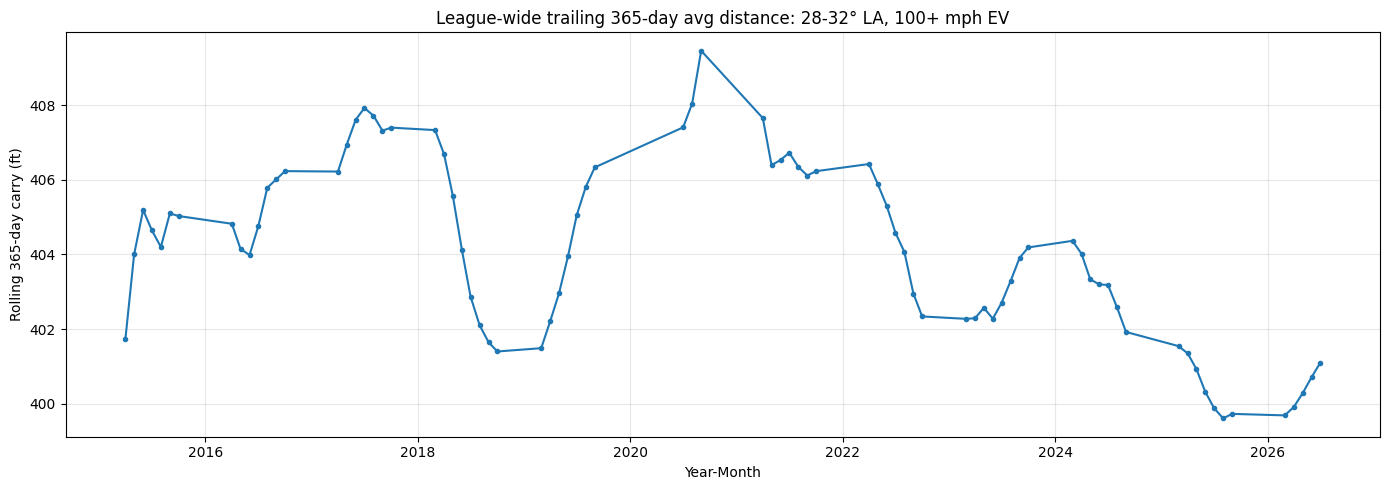

In [18]:
# --- Rolling carry over time, grouped by year_month ---
weather_dataset['year_month'] = weather_dataset['date'].dt.to_period('M')

carry_by_month = (
    weather_dataset.groupby('year_month')['rolling_carry_365d']
    .mean()
    .dropna()
)

plt.figure(figsize=(14, 5))
plt.plot(carry_by_month.index.to_timestamp(), carry_by_month.values, marker='o', markersize=3)
plt.xlabel('Year-Month')
plt.ylabel('Rolling 365-day carry (ft)')
plt.title('League-wide trailing 365-day avg distance: 28-32° LA, 100+ mph EV')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Model 1. Distance

##### Settings

In [19]:
distance_configs = {
    # "Torch_Base_B64":        ([64, 32, 16],       0.0,   0.001, 64,  0.05),
    # "Torch_Wide_B32":        ([128, 64, 32],      0.0,   0.001, 32,  0.05),
    # "Torch_Wider_B64":       ([256, 128, 64],     0.0,   0.001, 64,  0.05),
    # "Torch_Deep_B32":        ([256, 128, 64, 32], 0.0,   0.001, 32,  0.10),
    "Torch_Wide_WeightDecay":([128, 64, 32],      1e-5,  0.001, 64,  0.03),
}
distance_ensembles = 1
distance_random_states = 1
n_epochs = 20
batch_size = 1024

distance_quantiles = 10

##### Train

In [20]:
# --- Data prep ---
features_cont = ['launch_speed', 'launch_angle', 'temperature_2m', 'dew_point_2m', 'surface_pressure', 'wind_push', 'rolling_carry_365d']
target = 'hit_distance_sc'
cat_feature = 'venue_id'
date_col = 'date'

reg_df = weather_dataset[features_cont + [cat_feature, target, date_col]].dropna().reset_index(drop=True)
reg_df['_date_str'] = pd.to_datetime(reg_df[date_col]).dt.strftime('%Y%m%d')

train_mask = (reg_df['_date_str'] >= min_training_date) & (reg_df['_date_str'] <= max_training_date)
test_mask  = (reg_df['_date_str'] >= min_testing_date)  & (reg_df['_date_str'] <= max_testing_date)

train_df = reg_df[train_mask].reset_index(drop=True)
test_df  = reg_df[test_mask].reset_index(drop=True)

print(f"Train: {len(train_df):,} rows ({train_df['_date_str'].min()} - {train_df['_date_str'].max()})")
print(f"Test:  {len(test_df):,} rows ({test_df['_date_str'].min()} - {test_df['_date_str'].max()})")

venue_cats = train_df[cat_feature].astype('category')
venue_cat_dtype = venue_cats.dtype

train_df['venue_id_enc'] = venue_cats.cat.codes
test_df['venue_id_enc'] = test_df[cat_feature].astype(venue_cat_dtype).cat.codes
n_venues = len(venue_cat_dtype.categories)

unseen_venues = (test_df['venue_id_enc'] == -1).sum()
if unseen_venues:
    print(f"Dropping {unseen_venues} test rows with venues unseen in training")
    test_df = test_df[test_df['venue_id_enc'] != -1].reset_index(drop=True)

X_cont_train = train_df[features_cont].values.astype(np.float32)
X_cat_train  = train_df['venue_id_enc'].values.astype(np.int64)
y_train      = train_df[target].values.astype(np.float32)

X_cont_val = test_df[features_cont].values.astype(np.float32)
X_cat_val  = test_df['venue_id_enc'].values.astype(np.int64)
y_val      = test_df[target].values.astype(np.float32)

scaler = StandardScaler()
X_cont_train = scaler.fit_transform(X_cont_train).astype(np.float32)
X_cont_val = scaler.transform(X_cont_val).astype(np.float32)

class DistanceDataset(Dataset):
    def __init__(self, X_cont, X_cat, y):
        self.X_cont = torch.tensor(X_cont)
        self.X_cat = torch.tensor(X_cat)
        self.y = torch.tensor(y).unsqueeze(1)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X_cont[idx], self.X_cat[idx], self.y[idx]

class DistanceNet(nn.Module):
    def __init__(self, n_cont, n_venues, hidden_dims, dropout, embed_dim=8):
        super().__init__()
        self.embed_dim = max(1, min(embed_dim, (n_venues + 1) // 2))
        self.venue_embed = nn.Embedding(n_venues, self.embed_dim)
        layers, prev = [], n_cont + self.embed_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x_cont, x_cat):
        v = self.venue_embed(x_cat)
        return self.net(torch.cat([x_cont, v], dim=1))

results = {}

for config_name, (hidden_dims, weight_decay, lr, cfg_batch_size, dropout) in distance_configs.items():
    for rs in range(distance_random_states):
        torch.manual_seed(rs)
        for member in range(distance_ensembles):
            train_loader = DataLoader(DistanceDataset(X_cont_train, X_cat_train, y_train),
                                       batch_size=cfg_batch_size, shuffle=True)
            val_loader = DataLoader(DistanceDataset(X_cont_val, X_cat_val, y_val),
                                     batch_size=batch_size, shuffle=False)

            model = DistanceNet(len(features_cont), n_venues, hidden_dims, dropout).to(device)
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
            loss_fn = nn.MSELoss()

            best_val_mse = float('inf')
            best_state = None
            best_epoch = -1

            for epoch in range(n_epochs):
                model.train()
                for xb_cont, xb_cat, yb in train_loader:
                    xb_cont, xb_cat, yb = xb_cont.to(device), xb_cat.to(device), yb.to(device)
                    optimizer.zero_grad()
                    loss = loss_fn(model(xb_cont, xb_cat), yb)
                    loss.backward()
                    optimizer.step()

                model.eval()
                with torch.no_grad():
                    val_loss, n = 0.0, 0
                    for xb_cont, xb_cat, yb in val_loader:
                        xb_cont, xb_cat, yb = xb_cont.to(device), xb_cat.to(device), yb.to(device)
                        val_loss += loss_fn(model(xb_cont, xb_cat), yb).item() * len(yb)
                        n += len(yb)
                    val_loss /= n

                if val_loss < best_val_mse:
                    best_val_mse = val_loss
                    best_state = copy.deepcopy(model.state_dict())
                    best_epoch = epoch + 1

                print(f"[{config_name}][rs={rs}][m={member}] epoch {epoch+1}/{n_epochs} val_mse={val_loss:.3f}")

            model.load_state_dict(best_state)

            results[(config_name, rs, member)] = {
                'model': model, 'val_mse': best_val_mse, 'best_epoch': best_epoch,
                'scaler': scaler, 'venue_categories': venue_cat_dtype.categories,
            }
            print(f"[{config_name}][rs={rs}][m={member}] restored best epoch {best_epoch} (val_mse={best_val_mse:.3f})")

print("\nSummary:")
for k, v in results.items():
    print(k, f"best_epoch={v['best_epoch']} val_rmse={v['val_mse']**0.5:.3f} ft")

Train: 872,571 rows (20180329 - 20250928)
Test:  64,738 rows (20260326 - 20260630)
[Torch_Wide_WeightDecay][rs=0][m=0] epoch 1/20 val_mse=252.653
[Torch_Wide_WeightDecay][rs=0][m=0] epoch 2/20 val_mse=245.918
[Torch_Wide_WeightDecay][rs=0][m=0] epoch 3/20 val_mse=242.050
[Torch_Wide_WeightDecay][rs=0][m=0] epoch 4/20 val_mse=246.029
[Torch_Wide_WeightDecay][rs=0][m=0] epoch 5/20 val_mse=248.371
[Torch_Wide_WeightDecay][rs=0][m=0] epoch 6/20 val_mse=248.603
[Torch_Wide_WeightDecay][rs=0][m=0] epoch 7/20 val_mse=239.971
[Torch_Wide_WeightDecay][rs=0][m=0] epoch 8/20 val_mse=240.379
[Torch_Wide_WeightDecay][rs=0][m=0] epoch 9/20 val_mse=247.737
[Torch_Wide_WeightDecay][rs=0][m=0] epoch 10/20 val_mse=235.721
[Torch_Wide_WeightDecay][rs=0][m=0] epoch 11/20 val_mse=238.529
[Torch_Wide_WeightDecay][rs=0][m=0] epoch 12/20 val_mse=235.764
[Torch_Wide_WeightDecay][rs=0][m=0] epoch 13/20 val_mse=239.451
[Torch_Wide_WeightDecay][rs=0][m=0] epoch 14/20 val_mse=238.343
[Torch_Wide_WeightDecay][rs=0]

##### Best Model

In [21]:
# Get predictions from the best model in results (lowest val_mse)
best_key = min(results, key=lambda k: results[k]['val_mse'])
best_model = results[best_key]['model']

best_model.eval()

with torch.no_grad():
    X_cont_val_t = torch.tensor(X_cont_val).to(device)
    X_cat_val_t = torch.tensor(X_cat_val).to(device)
    preds = best_model(X_cont_val_t, X_cat_val_t).cpu().numpy().flatten()

test_df['predicted_distance'] = preds

# Bucket by predicted distance into deciles
test_df['pred_distance_bin'] = pd.qcut(test_df['predicted_distance'], distance_quantiles)

best_key

('Torch_Wide_WeightDecay', 0, 0)

##### Overall

In [22]:
quantile_summary = test_df.groupby('pred_distance_bin', observed=True).agg(
    predicted_mean=('predicted_distance', 'mean'),
    actual_mean=(target, 'mean'),
    count=(target, 'size')
)
quantile_summary['diff'] = quantile_summary['actual_mean'] - quantile_summary['predicted_mean']

quantile_summary.reset_index()

,pred_distance_bin,predicted_mean,actual_mean,count,diff
0,"(-0.664, 6.737]",4.638457,3.061786,6474,-1.576672
1,"(6.737, 14.771]",9.840618,8.664350,6474,-1.176268
2,"(14.771, 41.042]",25.463757,23.499073,6474,-1.964683
3,"(41.042, 99.893]",68.763031,64.406458,6473,-4.356573
4,"(99.893, 165.457]",132.811279,129.242972,6474,-3.568307
5,"(165.457, 220.515]",193.320450,189.852487,6474,-3.467963
6,"(220.515, 267.156]",244.365707,242.452649,6473,-1.913058
7,"(267.156, 308.199]",287.643066,287.289002,6474,-0.354064
8,"(308.199, 350.574]",329.268890,329.444393,6474,0.175503
9,"(350.574, 462.692]",378.730652,379.833179,6474,1.102527


##### Venue

In [23]:
# Build venue_id -> venue_name mapping using the most recent name per venue_id
venue_names = (
    weather_dataset[['venue_id', 'venue_name', date_col]]
    .dropna(subset=['venue_id', 'venue_name'])
    .sort_values(date_col)
    .groupby('venue_id')['venue_name']
    .last()
)

# Identify the top quantile bin (highest predicted distance)
top_bin = test_df['pred_distance_bin'].cat.categories[-1]

venue_top_quantile = (
    test_df[test_df['pred_distance_bin'] == top_bin]
    .groupby('venue_id', observed=True)
    .agg(
        predicted_mean=('predicted_distance', 'mean'),
        actual_mean=(target, 'mean'),
        count=(target, 'size')
    )
)
venue_top_quantile['diff'] = venue_top_quantile['actual_mean'] - venue_top_quantile['predicted_mean']
venue_top_quantile['venue_name'] = venue_top_quantile.index.map(venue_names)
venue_top_quantile = venue_top_quantile[['venue_name', 'predicted_mean', 'actual_mean', 'count', 'diff']]
venue_top_quantile = venue_top_quantile.sort_values('actual_mean', ascending=False)
venue_top_quantile = venue_top_quantile.reset_index()

venue_top_quantile_styled = (
    venue_top_quantile.style
    .format({'predicted_mean': '{:.1f}', 'actual_mean': '{:.1f}', 'diff': '{:+.1f}', 'count': '{:,.0f}'})
    .bar(subset=['diff'], align='mid', color=['#C44E52', '#4C72B0'])
    .set_properties(**{'text-align': 'center'})
    .hide(axis='index')
)

venue_top_quantile_styled

venue_id,venue_name,predicted_mean,actual_mean,count,diff
19,Coors Field,383.9,390.8,292,+6.9
12,Tropicana Field,382.2,384.3,247,+2.1
3309,Nationals Park,381.3,383.1,253,+1.8
17,Wrigley Field,380.3,382.5,209,+2.3
15,Chase Field,381.7,382.4,253,+0.6
32,American Family Field,377.1,382.2,200,+5.1
7,Kauffman Stadium,380.6,381.8,229,+1.2
5325,Globe Life Field,377.5,381.6,196,+4.1
2681,Citizens Bank Park,378.1,381.6,208,+3.5
2395,Oracle Park,376.3,381.4,156,+5.1


### Park Dimensions (utility)
Loads fence-geometry reference data and defines the interpolation used to add wall-distance/wall-height features to Model 2. Pure utility here -- no `events_df` dependency, since Model 2's data prep (below) needs these functions already defined.

##### Load base dimension data + crosswalk

In [24]:
park_config = pd.read_csv(os.path.join(baseball_path, "Utilities", "ParkConfig.csv"))
park_venue_crosswalk = pd.read_csv(os.path.join(baseball_path, "Utilities", "Venue Crosswalk.csv"))

print(f"ParkConfig: {len(park_config):,} park-year rows, {park_config['parkID'].nunique()} parks")
print(f"Crosswalk: {len(park_venue_crosswalk)} parks mapped to venue_id")

ParkConfig: 3,150 park-year rows, 263 parks
Crosswalk: 36 parks mapped to venue_id


##### Manual dimension overrides
For park-years where ParkConfig.csv is known wrong or missing (confirmed via news reporting / official releases, cross-checked across multiple sources). Rows marked LOW CONFIDENCE are placeholders to verify against an official source before fully trusting.

In [25]:
dimension_overrides = [
    # --- Camden Yards "Walltimore" era (2022-2024) ---
    # ParkConfig.csv incorrectly carries pre-2022 numbers through these years.
    {'parkID': 'BAL12', 'Year': 2022, 'LF_Dim': 333, 'LC_Dim': 384, 'LCC_Dim': 398, 'CF_Dim': 400,
     'RC_Dim': 373, 'RF_Dim': 318, 'LF_W': 13, 'LC_W': 13, 'CF_W': 7, 'RC_W': 7, 'RF_W': 21},
    {'parkID': 'BAL12', 'Year': 2023, 'LF_Dim': 333, 'LC_Dim': 384, 'LCC_Dim': 398, 'CF_Dim': 400,
     'RC_Dim': 373, 'RF_Dim': 318, 'LF_W': 13, 'LC_W': 13, 'CF_W': 7, 'RC_W': 7, 'RF_W': 21},
    {'parkID': 'BAL12', 'Year': 2024, 'LF_Dim': 333, 'LC_Dim': 384, 'LCC_Dim': 398, 'CF_Dim': 400,
     'RC_Dim': 373, 'RF_Dim': 318, 'LF_W': 13, 'LC_W': 13, 'CF_W': 7, 'RC_W': 7, 'RF_W': 21},

    # --- Camden Yards, second change (2025-present) ---
    {'parkID': 'BAL12', 'Year': 2025, 'LF_Dim': 333, 'LC_Dim': 374, 'LCC_Dim': 410, 'CF_Dim': 400,
     'RC_Dim': 373, 'RF_Dim': 318, 'LF_W': 8, 'LC_W': 7, 'CF_W': 7, 'RC_W': 7, 'RF_W': 21},
    {'parkID': 'BAL12', 'Year': 2026, 'LF_Dim': 333, 'LC_Dim': 374, 'LCC_Dim': 410, 'CF_Dim': 400,
     'RC_Dim': 373, 'RF_Dim': 318, 'LF_W': 8, 'LC_W': 7, 'CF_W': 7, 'RC_W': 7, 'RF_W': 21},

    # --- Kauffman Stadium, 2026 change ---
    # HIGH CONFIDENCE: cross-checked across MLB.com, ESPN, Royals Review, WKZO, KWCH, AOL.
    # Corners in 9ft, straightaway in 9ft, gaps in ~8-10ft (sources vary slightly on gap amount),
    # center unchanged at 410. Height 10ft -> 8.5ft (see note below on the historical height gap).
    {'parkID': 'KAN06', 'Year': 2026, 'LF_Dim': 347, 'SLF_Dim': 364, 'LC_Dim': 379, 'CF_Dim': 410,
     'RC_Dim': 379, 'SRF_Dim': 364, 'RF_Dim': 344,
     'LF_W': 8.5, 'LC_W': 8.5, 'CF_W': 8.5, 'RC_W': 8.5, 'RF_W': 8.5},

    # NOTE: multiple independent sources describe Kauffman's PRE-2026 height as 10ft, but
    # ParkConfig.csv has it at 8.0 for every year 2001-2025. That's a likely-wrong historical
    # baseline this override does not yet fix -- see chat for the decision on whether/how to
    # patch it (would affect every pre-2026 Kauffman row's wall_height feature, not just 2026).

    # --- Sutter Health Park (Athletics' temporary home, 2025-2027) ---
    # LOW CONFIDENCE on height -- no official per-point chart found, descriptive estimate only.
    {'parkID': 'SAC01', 'Year': 2025, 'LF_Dim': 330, 'CF_Dim': 403, 'RF_Dim': 325,
     'LF_W': 9, 'CF_W': 9, 'RF_W': 9},
    {'parkID': 'SAC01', 'Year': 2026, 'LF_Dim': 330, 'CF_Dim': 403, 'RF_Dim': 325,
     'LF_W': 9, 'CF_W': 9, 'RF_W': 9},
]

dimension_overrides_df = pd.DataFrame(dimension_overrides)

override_keys = set(zip(dimension_overrides_df['parkID'], dimension_overrides_df['Year']))
mask_overridden = park_config.apply(lambda r: (r['parkID'], r['Year']) in override_keys, axis=1)
print(f"Replacing {mask_overridden.sum()} existing rows, adding {len(dimension_overrides_df) - mask_overridden.sum()} new rows")

park_config_patched = pd.concat(
    [park_config[~mask_overridden], dimension_overrides_df],
    ignore_index=True
).sort_values(['parkID', 'Year']).reset_index(drop=True)

Replacing 3 existing rows, adding 5 new rows


##### Angle convention
**Assumption requiring validation**: the 11 named distance columns are assumed evenly spaced from the left-field foul line (-45°) to dead center (0°) to the right-field foul line (+45°), matching the 45°-foul-line convention already used in `spray_angle`. Height uses the coarser 5-point scheme at the same angles. **The sign (which physical side is negative vs. positive) must be checked against `spray_angle`'s actual convention before trusting model output.**

In [26]:
DIST_ANGLE_MAP = {
    'LF_Dim': -45, 'SLF_Dim': -36, 'LFA_Dim': -27, 'LC_Dim': -18, 'LCC_Dim': -9, 'CF_Dim': 0,
    'RCC_Dim': 9, 'RC_Dim': 18, 'RFA_Dim': 27, 'SRF_Dim': 36, 'RF_Dim': 45,
}
HEIGHT_ANGLE_MAP = {
    'LF_W': -45, 'LC_W': -18, 'CF_W': 0, 'RC_W': 18, 'RF_W': 45,
}

##### Interpolation functions
`get_wall_geometry` — single lookup (used for one-time feature engineering over historical rows).
`get_wall_geometry_vectorized` — looks up the park-year row once, then interpolates an entire array of spray angles at once (used inside `simulate_game`, where the same game gets replayed against thousands of sample balls -- avoids a per-ball Python loop in the hot path).

In [27]:
def _angle_points(row, angle_map):
    points = [(angle, row[col]) for col, angle in angle_map.items()
              if col in row.index and pd.notna(row[col])]
    points.sort(key=lambda p: p[0])
    return points

def _lookup_park_year_row(parkID, year):
    available_years = park_config_patched.loc[park_config_patched['parkID'] == parkID, 'Year']
    if len(available_years) == 0:
        return None
    if year not in available_years.values:
        candidates = available_years[available_years <= year]
        year = candidates.max() if len(candidates) else available_years.max()
    row = park_year_index.loc[(parkID, year)]
    if isinstance(row, pd.DataFrame):  # duplicate (parkID, Year) rows -- take the first
        row = row.iloc[0]
    return row

park_year_index = park_config_patched.set_index(['parkID', 'Year'])

def get_wall_geometry(parkID, year, spray_angle):
    """Single-value lookup: returns (wall_distance, wall_height) for one park, year, spray_angle."""
    row = _lookup_park_year_row(parkID, year)
    if row is None:
        return np.nan, np.nan
    dist_points = _angle_points(row, DIST_ANGLE_MAP)
    height_points = _angle_points(row, HEIGHT_ANGLE_MAP)
    distance = np.interp(spray_angle, [p[0] for p in dist_points], [p[1] for p in dist_points]) if dist_points else np.nan
    height = np.interp(spray_angle, [p[0] for p in height_points], [p[1] for p in height_points]) if height_points else np.nan
    return distance, height

def get_wall_geometry_vectorized(parkID, year, spray_angles):
    """Array lookup: same park/year applied across many spray angles at once (e.g. a whole sample)."""
    row = _lookup_park_year_row(parkID, year)
    if row is None:
        nan_arr = np.full(len(spray_angles), np.nan)
        return nan_arr, nan_arr
    dist_points = _angle_points(row, DIST_ANGLE_MAP)
    height_points = _angle_points(row, HEIGHT_ANGLE_MAP)
    distance = np.interp(spray_angles, [p[0] for p in dist_points], [p[1] for p in dist_points]) if dist_points else np.full(len(spray_angles), np.nan)
    height = np.interp(spray_angles, [p[0] for p in height_points], [p[1] for p in height_points]) if height_points else np.full(len(spray_angles), np.nan)
    return distance, height

### Model 2. Outcome

##### Settings

In [28]:
events_configs = {
    # "Torch_Events_Base_B64":         ([64, 32, 16],       0.0,   0.001, 64,  0.05),
    # "Torch_Events_Wide_B32":         ([128, 64, 32],      0.0,   0.001, 32,  0.05),
    "Torch_Events_Wide_B64":         ([128, 64, 32],      0.0,   0.001, 64,  0.05),
    # "Torch_Events_Deep_B32":         ([256, 128, 64, 32], 0.0,   0.001, 32,  0.10),
    # "Torch_Events_WeightDecay":      ([128, 64, 32],      1e-5,  0.001, 64,  0.03),
}
events_ensembles = 1
events_random_states = 1
events_n_epochs = 20
events_batch_size = 1024

##### Train

In [29]:
# --- Data prep ---
events_features_cont = ['launch_angle', 'spray_angle', 'hit_distance_sc']
events_cat_feature = 'venue_id'
events_target = 'eventsModel'
date_col = 'date'

events_df = weather_dataset[['batSide', 'gamePk'] + events_features_cont + [events_cat_feature, events_target, date_col]].dropna().reset_index(drop=True)
events_df['b_L'] = (events_df['batSide'] == 'L').astype(np.float32)
events_features_cont = events_features_cont + ['b_L']

# --- Wall geometry features (Option 2) ---
events_df = events_df.merge(park_venue_crosswalk[['parkID', 'venue_id']], on='venue_id', how='left')
events_df['year'] = pd.to_datetime(events_df[date_col]).dt.year

wall_geo = events_df.apply(
    lambda r: get_wall_geometry(r['parkID'], r['year'], r['spray_angle'])
    if pd.notna(r['parkID']) else (np.nan, np.nan),
    axis=1, result_type='expand'
)
events_df[['wall_distance', 'wall_height']] = wall_geo
events_df['distance_past_wall'] = events_df['hit_distance_sc'] - events_df['wall_distance']

n_before = len(events_df)
events_df = events_df.dropna(subset=['wall_distance', 'wall_height']).reset_index(drop=True)
print(f"Dropped {n_before - len(events_df):,} rows with no wall-geometry match (venue not in crosswalk)")

events_features_cont = events_features_cont + ['wall_distance', 'wall_height', 'distance_past_wall']
print(f"events_features_cont now: {events_features_cont}")

events_df['_date_str'] = pd.to_datetime(events_df[date_col]).dt.strftime('%Y%m%d')

events_train_mask = (events_df['_date_str'] >= min_training_date) & (events_df['_date_str'] <= max_training_date)
events_test_mask  = (events_df['_date_str'] >= min_testing_date)  & (events_df['_date_str'] <= max_testing_date)

events_train_df = events_df[events_train_mask].reset_index(drop=True)
events_test_df  = events_df[events_test_mask].reset_index(drop=True)

print(f"Train: {len(events_train_df):,} rows ({events_train_df['_date_str'].min()} - {events_train_df['_date_str'].max()})")
print(f"Test:  {len(events_test_df):,} rows ({events_test_df['_date_str'].min()} - {events_test_df['_date_str'].max()})")

# Venue encoding (fit on train)
events_venue_cats = events_train_df[events_cat_feature].astype('category')
events_venue_cat_dtype = events_venue_cats.dtype

events_train_df['venue_id_enc'] = events_venue_cats.cat.codes
events_test_df['venue_id_enc'] = events_test_df[events_cat_feature].astype(events_venue_cat_dtype).cat.codes
events_n_venues = len(events_venue_cat_dtype.categories)

events_unseen_venues = (events_test_df['venue_id_enc'] == -1).sum()
if events_unseen_venues:
    print(f"Dropping {events_unseen_venues} test rows with venues unseen in training")
    events_test_df = events_test_df[events_test_df['venue_id_enc'] != -1].reset_index(drop=True)

# Target encoding (fit on train)
events_target_cats = events_train_df[events_target].astype('category')
events_target_cat_dtype = events_target_cats.dtype
events_n_classes = len(events_target_cat_dtype.categories)

events_train_df['target_enc'] = events_target_cats.cat.codes
events_test_df['target_enc'] = events_test_df[events_target].astype(events_target_cat_dtype).cat.codes

events_unseen_classes = (events_test_df['target_enc'] == -1).sum()
if events_unseen_classes:
    print(f"Dropping {events_unseen_classes} test rows with unseen event classes")
    events_test_df = events_test_df[events_test_df['target_enc'] != -1].reset_index(drop=True)

print(f"Classes ({events_n_classes}): {list(events_target_cat_dtype.categories)}")

X_cont_train_ev = events_train_df[events_features_cont].values.astype(np.float32)
X_cat_train_ev  = events_train_df['venue_id_enc'].values.astype(np.int64)
y_train_ev      = events_train_df['target_enc'].values.astype(np.int64)

X_cont_val_ev = events_test_df[events_features_cont].values.astype(np.float32)
X_cat_val_ev  = events_test_df['venue_id_enc'].values.astype(np.int64)
y_val_ev      = events_test_df['target_enc'].values.astype(np.int64)

events_scaler = StandardScaler()
X_cont_train_ev = events_scaler.fit_transform(X_cont_train_ev).astype(np.float32)
X_cont_val_ev = events_scaler.transform(X_cont_val_ev).astype(np.float32)

class EventsDataset(Dataset):
    def __init__(self, X_cont, X_cat, y):
        self.X_cont = torch.tensor(X_cont)
        self.X_cat = torch.tensor(X_cat)
        self.y = torch.tensor(y)  # class indices, not unsqueezed
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X_cont[idx], self.X_cat[idx], self.y[idx]

class EventsNet(nn.Module):
    def __init__(self, n_cont, n_venues, n_classes, hidden_dims, dropout, embed_dim=8):
        super().__init__()
        self.embed_dim = max(1, min(embed_dim, (n_venues + 1) // 2))
        self.venue_embed = nn.Embedding(n_venues, self.embed_dim)
        layers, prev = [], n_cont + self.embed_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x_cont, x_cat):
        v = self.venue_embed(x_cat)
        return self.net(torch.cat([x_cont, v], dim=1))  # raw logits

events_results = {}

for config_name, (hidden_dims, weight_decay, lr, cfg_batch_size, dropout) in events_configs.items():
    for rs in range(events_random_states):
        torch.manual_seed(rs)
        for member in range(events_ensembles):
            train_loader = DataLoader(EventsDataset(X_cont_train_ev, X_cat_train_ev, y_train_ev),
                                       batch_size=cfg_batch_size, shuffle=True)
            val_loader = DataLoader(EventsDataset(X_cont_val_ev, X_cat_val_ev, y_val_ev),
                                     batch_size=events_batch_size, shuffle=False)

            model = EventsNet(len(events_features_cont), events_n_venues, events_n_classes, hidden_dims, dropout).to(device)
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
            loss_fn = nn.CrossEntropyLoss()

            best_val_loss = float('inf')
            best_state = None
            best_epoch = -1

            for epoch in range(events_n_epochs):
                model.train()
                for xb_cont, xb_cat, yb in train_loader:
                    xb_cont, xb_cat, yb = xb_cont.to(device), xb_cat.to(device), yb.to(device)
                    optimizer.zero_grad()
                    loss = loss_fn(model(xb_cont, xb_cat), yb)
                    loss.backward()
                    optimizer.step()

                model.eval()
                with torch.no_grad():
                    val_loss, correct, n = 0.0, 0, 0
                    for xb_cont, xb_cat, yb in val_loader:
                        xb_cont, xb_cat, yb = xb_cont.to(device), xb_cat.to(device), yb.to(device)
                        logits = model(xb_cont, xb_cat)
                        val_loss += loss_fn(logits, yb).item() * len(yb)
                        correct += (logits.argmax(dim=1) == yb).sum().item()
                        n += len(yb)
                    val_loss /= n
                    val_acc = correct / n

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_state = copy.deepcopy(model.state_dict())
                    best_epoch = epoch + 1

                print(f"[{config_name}][rs={rs}][m={member}] epoch {epoch+1}/{events_n_epochs} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

            model.load_state_dict(best_state)

            events_results[(config_name, rs, member)] = {
                'model': model, 'val_loss': best_val_loss, 'best_epoch': best_epoch,
                'scaler': events_scaler, 'venue_categories': events_venue_cat_dtype.categories,
                'target_categories': events_target_cat_dtype.categories,
            }
            print(f"[{config_name}][rs={rs}][m={member}] restored best epoch {best_epoch} (val_loss={best_val_loss:.4f})")

print("\nSummary:")
for k, v in events_results.items():
    print(k, f"best_epoch={v['best_epoch']} val_loss={v['val_loss']:.4f}")

Dropped 28,071 rows with no wall-geometry match (venue not in crosswalk)
events_features_cont now: ['launch_angle', 'spray_angle', 'hit_distance_sc', 'b_L', 'wall_distance', 'wall_height', 'distance_past_wall']
Train: 869,443 rows (20180329 - 20250928)
Test:  64,819 rows (20260325 - 20260630)
Classes (8): ['b1', 'b2', 'b3', 'fo', 'go', 'hr', 'lo', 'po']
[Torch_Events_Wide_B64][rs=0][m=0] epoch 1/20 val_loss=0.5366 val_acc=0.7910
[Torch_Events_Wide_B64][rs=0][m=0] epoch 2/20 val_loss=0.5021 val_acc=0.8034
[Torch_Events_Wide_B64][rs=0][m=0] epoch 3/20 val_loss=0.4839 val_acc=0.8139
[Torch_Events_Wide_B64][rs=0][m=0] epoch 4/20 val_loss=0.4785 val_acc=0.8172
[Torch_Events_Wide_B64][rs=0][m=0] epoch 5/20 val_loss=0.4773 val_acc=0.8175
[Torch_Events_Wide_B64][rs=0][m=0] epoch 6/20 val_loss=0.4720 val_acc=0.8195
[Torch_Events_Wide_B64][rs=0][m=0] epoch 7/20 val_loss=0.4725 val_acc=0.8229
[Torch_Events_Wide_B64][rs=0][m=0] epoch 8/20 val_loss=0.4670 val_acc=0.8203
[Torch_Events_Wide_B64][rs=0

##### Best Model

In [30]:
events_best_key = min(events_results, key=lambda k: events_results[k]['val_loss'])
events_best_model = events_results[events_best_key]['model']
events_classes = list(events_results[events_best_key]['target_categories'])

events_best_model.eval()
with torch.no_grad():
    X_cont_val_t = torch.tensor(X_cont_val_ev).to(device)
    X_cat_val_t = torch.tensor(X_cat_val_ev).to(device)
    logits = events_best_model(X_cont_val_t, X_cat_val_t)
    probs = torch.softmax(logits, dim=1).cpu().numpy()

# Attach predicted probability for each class as its own column
for i, cls in enumerate(events_classes):
    events_test_df[f'prob_{cls}'] = probs[:, i]

events_best_key

('Torch_Events_Wide_B64', 0, 0)

### PA Evaluations

Probably less helpful than evaluations aggregated on the game or venue level

##### Overall

In [31]:
woba_weights_eval = {'b1': 0.882, 'b2': 1.254, 'b3': 1.590, 'hr': 2.050, 'bb': 0.689, 'hbp': 0.720}

event_rate_summary = pd.DataFrame({
    'predicted_rate': {cls: events_test_df[f'prob_{cls}'].mean() for cls in events_classes},
    'actual_rate': {cls: (events_test_df[events_target] == cls).mean() for cls in events_classes},
})
event_rate_summary['diff'] = event_rate_summary['actual_rate'] - event_rate_summary['predicted_rate']
event_rate_summary['count'] = events_test_df[events_target].value_counts().reindex(events_classes)

event_rate_summary = event_rate_summary.sort_values('actual_rate', ascending=False)

# Weight vector aligned to events_classes order (0 for outs: go/lo/fo/po)
woba_weight_vec = np.array([woba_weights_eval.get(cls, 0.0) for cls in events_classes])

# Predicted wOBA per row = sum of prob_cls * weight_cls
prob_matrix = events_test_df[[f'prob_{cls}' for cls in events_classes]].values
events_test_df['predicted_woba'] = prob_matrix @ woba_weight_vec

# Actual wOBA per row = weight of the actual outcome (0 for outs)
events_test_df['actual_woba'] = events_test_df[events_target].map(woba_weights_eval).fillna(0.0)

# Add overall wOBA row to the event rate summary
woba_row = pd.DataFrame({
    'predicted_rate': [events_test_df['predicted_woba'].mean()],
    'actual_rate': [events_test_df['actual_woba'].mean()],
}, index=['wOBA (BIP)'])
woba_row['diff'] = woba_row['actual_rate'] - woba_row['predicted_rate']
woba_row['count'] = len(events_test_df)

event_rate_summary_with_woba = pd.concat([event_rate_summary, woba_row])
event_rate_summary_with_woba

,predicted_rate,actual_rate,diff,count
go,0.327791,0.322004,-0.005787,20872
b1,0.203224,0.208735,0.005511,13530
fo,0.203232,0.202178,-0.001054,13105
lo,0.087505,0.084111,-0.003394,5452
po,0.073858,0.072432,-0.001426,4695
b2,0.056197,0.061448,0.005251,3983
hr,0.042357,0.043938,0.001581,2848
b3,0.005835,0.005153,-0.000682,334
wOBA (BIP),0.345825,0.359426,0.013600,64819


In [32]:
woba_quantiles = 10

events_test_df['pred_woba_bin'] = pd.qcut(events_test_df['predicted_woba'], woba_quantiles)

woba_quantile_summary = events_test_df.groupby('pred_woba_bin', observed=True).agg(
    predicted_woba_mean=('predicted_woba', 'mean'),
    actual_woba_mean=('actual_woba', 'mean'),
    count=('actual_woba', 'size')
)
woba_quantile_summary['diff'] = woba_quantile_summary['actual_woba_mean'] - woba_quantile_summary['predicted_woba_mean']

woba_quantile_summary.reset_index()

,pred_woba_bin,predicted_woba_mean,actual_woba_mean,count,diff
0,"(-0.0009949100000000001, 0.00304]",0.001568,0.004765,6482,0.003197
1,"(0.00304, 0.0146]",0.007150,0.008425,6482,0.001274
2,"(0.0146, 0.0421]",0.029293,0.033052,6482,0.003759
3,"(0.0421, 0.083]",0.061189,0.064615,6482,0.003426
4,"(0.083, 0.139]",0.109192,0.109315,6482,0.000122
5,"(0.139, 0.233]",0.181638,0.190579,6481,0.008941
6,"(0.233, 0.388]",0.305953,0.324401,6482,0.018449
7,"(0.388, 0.64]",0.505877,0.544897,6482,0.039020
8,"(0.64, 0.889]",0.800364,0.831598,6482,0.031234
9,"(0.889, 2.05]",1.456003,1.482582,6482,0.026579


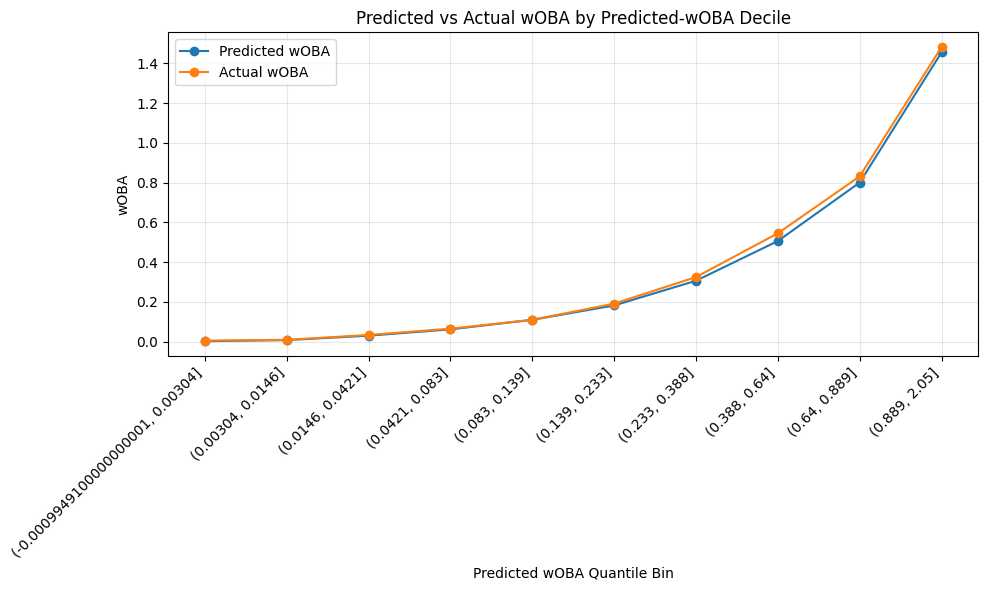

In [33]:
plt.figure(figsize=(10, 6))

x = range(len(woba_quantile_summary))
labels = [str(interval) for interval in woba_quantile_summary.index]

plt.plot(x, woba_quantile_summary['predicted_woba_mean'], marker='o', label='Predicted wOBA')
plt.plot(x, woba_quantile_summary['actual_woba_mean'], marker='o', label='Actual wOBA')

plt.xticks(x, labels, rotation=45, ha='right')
plt.xlabel('Predicted wOBA Quantile Bin')
plt.ylabel('wOBA')
plt.title('Predicted vs Actual wOBA by Predicted-wOBA Decile')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### Venue

In [34]:
venue_woba_summary = (
    events_test_df
    .groupby('venue_id', observed=True)
    .agg(
        predicted_woba_mean=('predicted_woba', 'mean'),
        actual_woba_mean=('actual_woba', 'mean'),
        count=('actual_woba', 'size')
    )
)
venue_woba_summary['diff'] = venue_woba_summary['actual_woba_mean'] - venue_woba_summary['predicted_woba_mean']
venue_woba_summary['venue_name'] = venue_woba_summary.index.map(venue_names)

venue_woba_summary = venue_woba_summary[['venue_name', 'predicted_woba_mean', 'actual_woba_mean', 'diff', 'count']]
venue_woba_summary = venue_woba_summary.sort_values('actual_woba_mean', ascending=False)

venue_woba_summary.reset_index()

,venue_id,venue_name,predicted_woba_mean,actual_woba_mean,diff,count
0,2529,Sutter Health Park,0.359629,0.402234,0.042605,2019
1,19,Coors Field,0.381651,0.402183,0.020532,2298
2,2602,Great American Ball Park,0.380527,0.391902,0.011376,1885
3,31,PNC Park,0.356407,0.387232,0.030826,2311
4,2681,Citizens Bank Park,0.367231,0.386296,0.019065,2226
5,3309,Nationals Park,0.372365,0.379982,0.007617,2272
6,3313,Yankee Stadium,0.360340,0.377291,0.016951,1900
7,2392,Daikin Park,0.364946,0.376282,0.011336,2073
8,7,Kauffman Stadium,0.365316,0.369926,0.004610,2234
9,2,Oriole Park at Camden Yards,0.352129,0.365469,0.013340,2417


### Simulate 

##### Settings

In [35]:
sim_sample_size = 50000
sim_random_state = 1

##### Sample

In [36]:
# Pool: training-window batted balls with everything both models need
weather_dataset['_date_str'] = pd.to_datetime(weather_dataset['date']).dt.strftime('%Y%m%d')

sim_pool = weather_dataset[
    (weather_dataset['_date_str'] >= min_training_date) &
    (weather_dataset['_date_str'] <= max_training_date)
].dropna(subset=['launch_speed', 'launch_angle', 'spray_angle', 'ball_dir_x', 'ball_dir_y',
                  'batSide', 'hit_distance_sc', 'eventsModel'])

# Only classes the events model actually knows (balls in play)
sim_pool = sim_pool[sim_pool['eventsModel'].isin(events_classes)]

sim_sample = sim_pool.sample(n=sim_sample_size, random_state=sim_random_state).reset_index(drop=True)

sim_sample_L = sim_sample[sim_sample['batSide'] == 'L'].reset_index(drop=True)
sim_sample_R = sim_sample[sim_sample['batSide'] == 'R'].reset_index(drop=True)

print(f"Sample: {len(sim_sample):,} ({len(sim_sample_L):,} L, {len(sim_sample_R):,} R)")

Sample: 50,000 (20,515 L, 29,485 R)


##### Baseline (actual, unmodified sample rates)

In [37]:
def compute_actual_rates(sample_df):
    rates = sample_df['eventsModel'].value_counts(normalize=True).reindex(events_classes).fillna(0.0).to_dict()
    rates['wOBA'] = sample_df['eventsModel'].map(woba_weights_eval).fillna(0.0).mean()
    return rates

baseline_rates_L = compute_actual_rates(sim_sample_L)
baseline_rates_R = compute_actual_rates(sim_sample_R)

##### Simulate one sample group under one game's conditions

In [38]:
def simulate_game(sample_df, game_row, direction):
    n = len(sample_df)
    if n == 0:
        return None

    # Recompute wind_push: sample's own flight direction + this game's wind vectors
    wind_push_sim = (
        game_row['meteo_x_vect'] * sample_df['ball_dir_x'].values +
        game_row['meteo_y_vect'] * sample_df['ball_dir_y'].values
    )

    # --- Model 1: simulate distance under this game's venue + weather ---
    X_cont_m1 = np.column_stack([
            sample_df['launch_speed'].values,
            sample_df['launch_angle'].values,
            np.full(n, game_row['temperature_2m']),
            np.full(n, game_row['dew_point_2m']),
            np.full(n, game_row['surface_pressure']),
            wind_push_sim,
            np.full(n, game_row['rolling_carry_365d'])
        ]).astype(np.float32)
    X_cont_m1 = scaler.transform(X_cont_m1).astype(np.float32)

    venue_code_m1 = pd.Series([game_row['venue_id']], dtype=venue_cat_dtype.categories.dtype).astype(venue_cat_dtype).cat.codes.iloc[0]
    X_cat_m1 = np.full(n, venue_code_m1, dtype=np.int64)

    with torch.no_grad():
        sim_distance = best_model(
            torch.tensor(X_cont_m1).to(device), torch.tensor(X_cat_m1).to(device)
        ).cpu().numpy().flatten()

    # --- Model 2: simulate event odds using simulated distance + this game's venue ---
    wall_distance_sim, wall_height_sim = get_wall_geometry_vectorized(
        game_row['parkID'], game_row['year'], sample_df['spray_angle'].values
    )
    distance_past_wall_sim = sim_distance - wall_distance_sim

    X_cont_m2 = np.column_stack([
        sample_df['launch_angle'].values,
        sample_df['spray_angle'].values,
        sim_distance,
        np.full(n, 1.0 if direction == 'L' else 0.0),
        wall_distance_sim,
        wall_height_sim,
        distance_past_wall_sim
    ]).astype(np.float32)
    X_cont_m2 = events_scaler.transform(X_cont_m2).astype(np.float32)

    venue_code_m2 = pd.Series([game_row['venue_id']], dtype=events_venue_cat_dtype.categories.dtype).astype(events_venue_cat_dtype).cat.codes.iloc[0]
    X_cat_m2 = np.full(n, venue_code_m2, dtype=np.int64)

    with torch.no_grad():
        logits = events_best_model(
            torch.tensor(X_cont_m2).to(device), torch.tensor(X_cat_m2).to(device)
        )
        probs = torch.softmax(logits, dim=1).cpu().numpy()

    mean_probs = probs.mean(axis=0)
    result = dict(zip(events_classes, mean_probs))
    result['wOBA'] = float(np.array([woba_weights_eval.get(c, 0.0) for c in events_classes]) @ mean_probs)
    return result

##### Run simulation (full history, once)
`sim_df` below is a filtered view of the full-history result for the test window -- the PA/venue evaluation cells that follow use it as before.

In [39]:
all_games = (
    weather_dataset
    .dropna(subset=['venue_id', 'temperature_2m', 'dew_point_2m', 'surface_pressure',
                     'meteo_x_vect', 'meteo_y_vect', 'rolling_carry_365d'])
    .drop_duplicates(subset='gamePk')
    [['gamePk', 'date', 'venue_id', 'temperature_2m', 'dew_point_2m', 'surface_pressure',
      'meteo_x_vect', 'meteo_y_vect', 'rolling_carry_365d']]
    .reset_index(drop=True)
)

# Both models need to recognize the venue
all_games = all_games[
    all_games['venue_id'].isin(venue_cat_dtype.categories) &
    all_games['venue_id'].isin(events_venue_cat_dtype.categories)
].reset_index(drop=True)

# Attach parkID + year for wall-geometry lookups
all_games = all_games.merge(park_venue_crosswalk[['parkID', 'venue_id']], on='venue_id', how='left')
all_games['year'] = pd.to_datetime(all_games['date']).dt.year

n_before = len(all_games)
all_games = all_games.dropna(subset=['parkID']).reset_index(drop=True)
if n_before - len(all_games):
    print(f"Dropping {n_before - len(all_games)} games at venues missing from the park/venue crosswalk")

# Flag which games fall in the test window -- used below to derive `sim_df`,
# the test-only subset the PA/venue evaluation cells expect, without
# re-running the simulation a second time just for that window.
all_games['_date_str'] = pd.to_datetime(all_games['date']).dt.strftime('%Y%m%d')
all_games['_is_test_window'] = (
    (all_games['_date_str'] >= min_testing_date) & (all_games['_date_str'] <= max_testing_date)
)

print(f"Simulating {len(all_games):,} games ({all_games['_is_test_window'].sum():,} in the test window)")

Simulating 25,833 games (1,272 in the test window)


In [40]:
history_sim_rows = []

for i, (_, game) in enumerate(all_games.iterrows()):
    row = {'gamePk': game['gamePk'], 'date': game['date'], 'venue_id': game['venue_id']}
    for side, sample_df in [('L', sim_sample_L), ('R', sim_sample_R)]:
        sim = simulate_game(sample_df, game, direction=side)
        if sim:
            for cls, val in sim.items():
                row[f'{side}_{cls}_sim'] = val
    history_sim_rows.append(row)

    if (i + 1) % 500 == 0:
        print(f"  {i + 1:,} / {len(all_games):,} games simulated")

history_sim_df = pd.DataFrame(history_sim_rows)
print(f"Done: {len(history_sim_df):,} games simulated")

for cls in events_classes + ['wOBA']:
    history_sim_df[f'L_{cls}_baseline'] = baseline_rates_L[cls]
    history_sim_df[f'R_{cls}_baseline'] = baseline_rates_R[cls]
    history_sim_df[f'L_{cls}_diff'] = history_sim_df[f'L_{cls}_sim'] - history_sim_df[f'L_{cls}_baseline']
    history_sim_df[f'R_{cls}_diff'] = history_sim_df[f'R_{cls}_sim'] - history_sim_df[f'R_{cls}_baseline']

# Test-window-only view -- everything below that expects `sim_df` (the PA/venue
# evaluation cells) uses this filtered subset rather than a separately-run simulation
sim_df = history_sim_df[all_games['_is_test_window'].values].reset_index(drop=True).copy()
print(f"sim_df (test window): {len(sim_df):,} games")

  500 / 25,833 games simulated
  1,000 / 25,833 games simulated
  1,500 / 25,833 games simulated
  2,000 / 25,833 games simulated
  2,500 / 25,833 games simulated
  3,000 / 25,833 games simulated
  3,500 / 25,833 games simulated
  4,000 / 25,833 games simulated
  4,500 / 25,833 games simulated
  5,000 / 25,833 games simulated
  5,500 / 25,833 games simulated
  6,000 / 25,833 games simulated
  6,500 / 25,833 games simulated
  7,000 / 25,833 games simulated
  7,500 / 25,833 games simulated
  8,000 / 25,833 games simulated
  8,500 / 25,833 games simulated
  9,000 / 25,833 games simulated
  9,500 / 25,833 games simulated
  10,000 / 25,833 games simulated
  10,500 / 25,833 games simulated
  11,000 / 25,833 games simulated
  11,500 / 25,833 games simulated
  12,000 / 25,833 games simulated
  12,500 / 25,833 games simulated
  13,000 / 25,833 games simulated
  13,500 / 25,833 games simulated
  14,000 / 25,833 games simulated
  14,500 / 25,833 games simulated
  15,000 / 25,833 games simulated
 

##### Game-level wOBA calibration

In [41]:
game_woba = (
    events_test_df.groupby('gamePk')
    .agg(
        predicted_woba=('predicted_woba', 'mean'),
        actual_woba=('actual_woba', 'mean'),
        n_pa=('actual_woba', 'size')
    )
    .reset_index()
)

game_woba['pred_woba_bin'] = pd.qcut(game_woba['predicted_woba'], woba_quantiles)

game_woba_quantile_summary = game_woba.groupby('pred_woba_bin', observed=True).agg(
    predicted_woba_mean=('predicted_woba', 'mean'),
    actual_woba_mean=('actual_woba', 'mean'),
    game_count=('gamePk', 'size'),
    avg_pa_per_game=('n_pa', 'mean')
)
game_woba_quantile_summary['diff'] = game_woba_quantile_summary['actual_woba_mean'] - game_woba_quantile_summary['predicted_woba_mean']

game_woba_quantile_summary.reset_index()

,pred_woba_bin,predicted_woba_mean,actual_woba_mean,game_count,avg_pa_per_game,diff
0,"(0.123, 0.253]",0.228248,0.240917,128,46.703125,0.012669
1,"(0.253, 0.282]",0.267853,0.278840,127,48.007874,0.010987
2,"(0.282, 0.307]",0.295109,0.303942,127,48.606299,0.008834
3,"(0.307, 0.323]",0.315560,0.325247,127,51.023622,0.009688
4,"(0.323, 0.338]",0.330283,0.345250,128,50.796875,0.014967
5,"(0.338, 0.356]",0.347381,0.361131,127,51.551181,0.013750
6,"(0.356, 0.38]",0.368627,0.379140,127,52.062992,0.010513
7,"(0.38, 0.402]",0.389712,0.404229,127,52.905512,0.014517
8,"(0.402, 0.432]",0.416367,0.426497,127,52.889764,0.010131
9,"(0.432, 0.609]",0.468178,0.482751,128,54.640625,0.014573


##### Plot

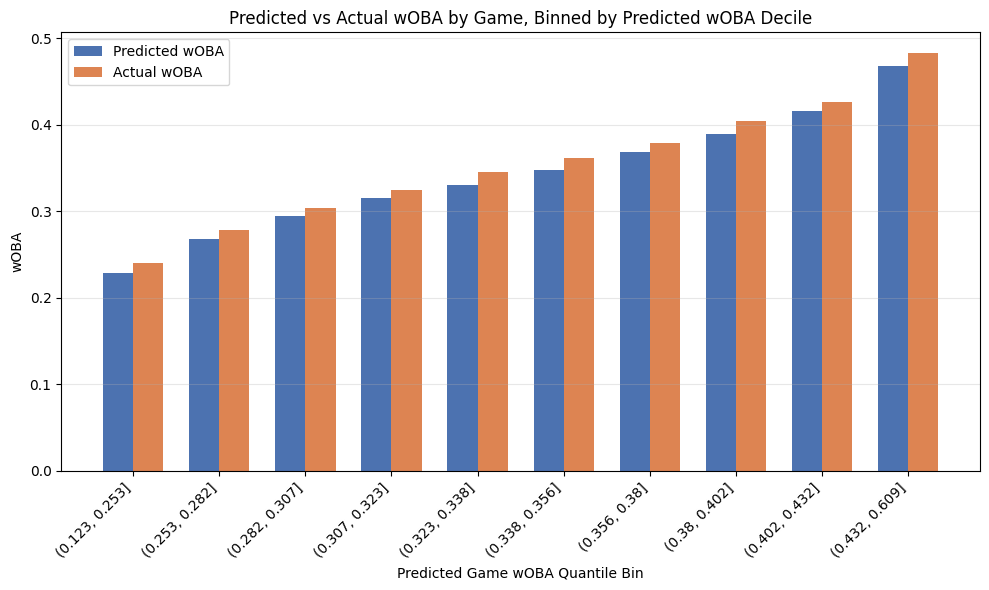

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(game_woba_quantile_summary))
width = 0.35

ax.bar(x - width/2, game_woba_quantile_summary['predicted_woba_mean'], width, label='Predicted wOBA', color='#4C72B0')
ax.bar(x + width/2, game_woba_quantile_summary['actual_woba_mean'], width, label='Actual wOBA', color='#DD8452')

ax.set_xlabel('Predicted Game wOBA Quantile Bin')
ax.set_ylabel('wOBA')
ax.set_title('Predicted vs Actual wOBA by Game, Binned by Predicted wOBA Decile')
ax.set_xticks(x)
ax.set_xticklabels([str(interval) for interval in game_woba_quantile_summary.index], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

##### Game-level wOBA, aggregated by venue

In [43]:
game_woba_venue = (
    events_test_df.groupby(['gamePk', 'venue_id'])
    .agg(
        predicted_woba=('predicted_woba', 'mean'),
        actual_woba=('actual_woba', 'mean'),
        n_pa=('actual_woba', 'size')
    )
    .reset_index()
)

venue_game_woba_summary = (
    game_woba_venue.groupby('venue_id', observed=True)
    .agg(
        predicted_woba_mean=('predicted_woba', 'mean'),
        actual_woba_mean=('actual_woba', 'mean'),
        game_count=('gamePk', 'size'),
        avg_pa_per_game=('n_pa', 'mean')
    )
)
venue_game_woba_summary['diff'] = venue_game_woba_summary['actual_woba_mean'] - venue_game_woba_summary['predicted_woba_mean']
venue_game_woba_summary['venue_name'] = venue_game_woba_summary.index.map(venue_names)

venue_game_woba_summary = venue_game_woba_summary[
    ['venue_name', 'predicted_woba_mean', 'actual_woba_mean', 'diff', 'game_count', 'avg_pa_per_game']
]
venue_game_woba_summary = venue_game_woba_summary.sort_values('actual_woba_mean', ascending=False)

venue_game_woba_summary[venue_game_woba_summary['game_count'] >= 81].reset_index()

,venue_id,venue_name,predicted_woba_mean,actual_woba_mean,diff,game_count,avg_pa_per_game


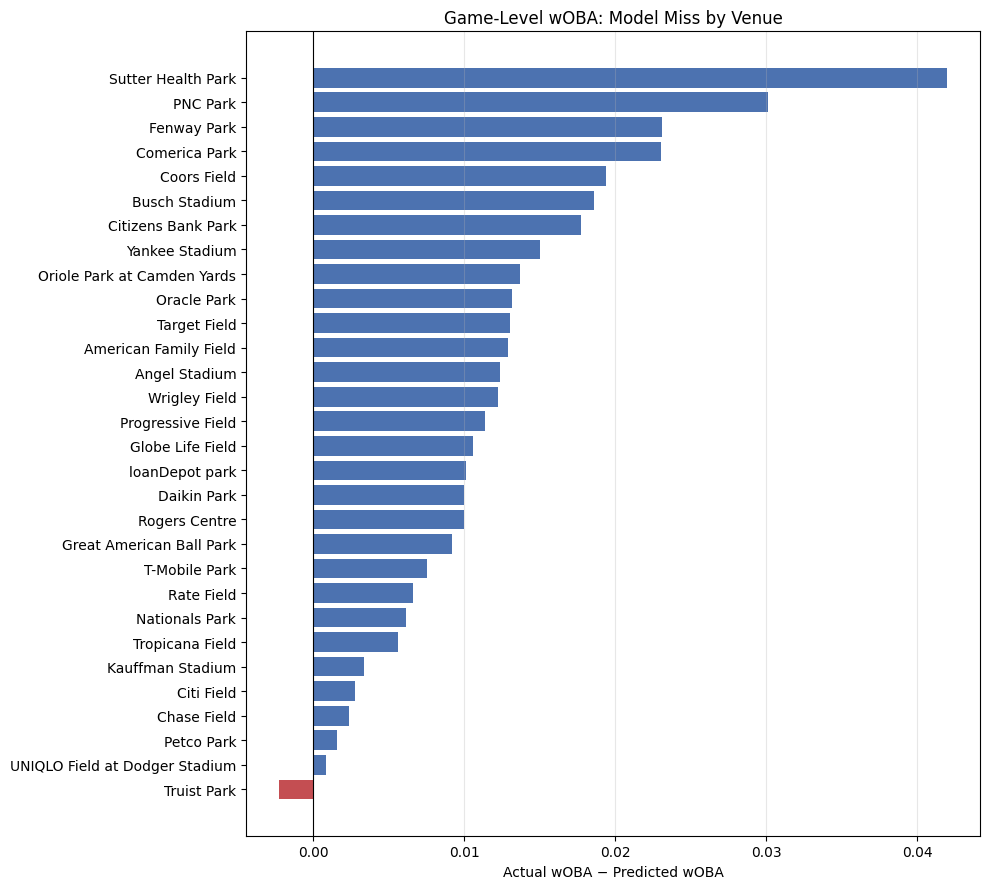

In [44]:
venue_sorted = venue_game_woba_summary[venue_game_woba_summary['game_count'] >= 1].sort_values('diff')

fig, ax = plt.subplots(figsize=(10, max(6, len(venue_sorted) * 0.3)))

colors = ['#C44E52' if d < 0 else '#4C72B0' for d in venue_sorted['diff']]
ax.barh(venue_sorted['venue_name'], venue_sorted['diff'], color=colors)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Actual wOBA − Predicted wOBA')
ax.set_title('Game-Level wOBA: Model Miss by Venue')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

##### Event multipliers (game-level, by side)

In [45]:
n_sample_L = len(sim_sample_L)
n_sample_R = len(sim_sample_R)

baseline_counts_L = sim_sample_L['eventsModel'].value_counts().reindex(events_classes).fillna(0)
baseline_counts_R = sim_sample_R['eventsModel'].value_counts().reindex(events_classes).fillna(0)

for cls in events_classes:
    sum_predicted_L = sim_df[f'L_{cls}_sim'] * n_sample_L
    sum_predicted_R = sim_df[f'R_{cls}_sim'] * n_sample_R

    sim_df[f'{cls}_wfx_unadj_l'] = sum_predicted_L / baseline_counts_L[cls]
    sim_df[f'{cls}_wfx_unadj_r'] = sum_predicted_R / baseline_counts_R[cls]

sim_df['woba_wfx_unadj_l'] = sim_df['L_wOBA_sim'] / baseline_rates_L['wOBA']
sim_df['woba_wfx_unadj_r'] = sim_df['R_wOBA_sim'] / baseline_rates_R['wOBA']

##### Venue multiplier comparison — single stat

In [46]:
# --- Actual game-level rates by side (needed to build actual_venue) ---
actual_game_rates = []
for side in ['L', 'R']:
    side_df = events_test_df[events_test_df['batSide'] == side]
    grp = side_df.groupby(['gamePk', 'venue_id'])[events_target]
    rates = grp.value_counts(normalize=True).unstack(fill_value=0).reindex(columns=events_classes, fill_value=0)
    rates['wOBA'] = side_df.groupby(['gamePk', 'venue_id'])['actual_woba'].mean()
    rates = rates.reset_index()
    rates['batSide'] = side
    actual_game_rates.append(rates)

actual_game_rates = pd.concat(actual_game_rates, ignore_index=True)

# --- Venue-level actual (average of per-game rates) ---
actual_venue = (
    actual_game_rates.groupby(['venue_id', 'batSide'])[events_classes + ['wOBA']]
    .mean()
    .reset_index()
)

# --- Predicted WFX multiplier by venue (mean of game-level WFX columns from sim_df) ---
predicted_mult_L = sim_df.groupby('venue_id')[[f'{c}_wfx_unadj_l' for c in events_classes] + ['woba_wfx_unadj_l']].mean()
predicted_mult_L.columns = events_classes + ['wOBA']
predicted_mult_L = predicted_mult_L.reset_index()
predicted_mult_L['batSide'] = 'L'

predicted_mult_R = sim_df.groupby('venue_id')[[f'{c}_wfx_unadj_r' for c in events_classes] + ['woba_wfx_unadj_r']].mean()
predicted_mult_R.columns = events_classes + ['wOBA']
predicted_mult_R = predicted_mult_R.reset_index()
predicted_mult_R['batSide'] = 'R'

predicted_mult = pd.concat([predicted_mult_L, predicted_mult_R], ignore_index=True)

# --- Actual multiplier by venue: venue's actual rate / neutral baseline rate ---
actual_mult = actual_venue.copy()
for cls in events_classes + ['wOBA']:
    baseline_val = actual_mult['batSide'].map({'L': baseline_rates_L[cls], 'R': baseline_rates_R[cls]})
    actual_mult[cls] = actual_mult[cls] / baseline_val

# --- Combine into tidy comparison ---
venue_multiplier_comparison = predicted_mult.melt(
    id_vars=['venue_id', 'batSide'], var_name='event', value_name='predicted_multiplier'
).merge(
    actual_mult.melt(id_vars=['venue_id', 'batSide'], var_name='event', value_name='actual_multiplier'),
    on=['venue_id', 'batSide', 'event']
)

venue_multiplier_comparison['diff'] = venue_multiplier_comparison['actual_multiplier'] - venue_multiplier_comparison['predicted_multiplier']
venue_multiplier_comparison['venue_name'] = venue_multiplier_comparison['venue_id'].map(venue_names)

venue_multiplier_comparison = venue_multiplier_comparison[
    ['venue_id', 'venue_name', 'batSide', 'event', 'predicted_multiplier', 'actual_multiplier', 'diff']
].sort_values(['venue_name', 'batSide', 'event'])

In [52]:
stat = 'wOBA'  # set to any value in events_classes, or 'wOBA'
batSide = 'R'

venue_stat_comparison = (
    venue_multiplier_comparison[venue_multiplier_comparison['event'] == stat][venue_multiplier_comparison['batSide'] == batSide]
    .sort_values('predicted_multiplier', ascending=False)
    .reset_index(drop=True)
)

venue_stat_comparison

,venue_id,venue_name,batSide,event,predicted_multiplier,actual_multiplier,diff
0,2602,Great American Ball Park,R,wOBA,1.000555,0.966488,-0.034067
1,19,Coors Field,R,wOBA,0.995274,1.030930,0.035655
2,7,Kauffman Stadium,R,wOBA,0.981370,0.945145,-0.036226
3,2392,Daikin Park,R,wOBA,0.980904,0.979117,-0.001787
4,2681,Citizens Bank Park,R,wOBA,0.976130,0.940235,-0.035895
5,2529,Sutter Health Park,R,wOBA,0.971105,1.074032,0.102927
6,32,American Family Field,R,wOBA,0.954220,0.942355,-0.011865
7,2,Oriole Park at Camden Yards,R,wOBA,0.951960,0.999964,0.048004
8,12,Tropicana Field,R,wOBA,0.950957,1.020861,0.069905
9,4,Rate Field,R,wOBA,0.948190,0.954922,0.006732


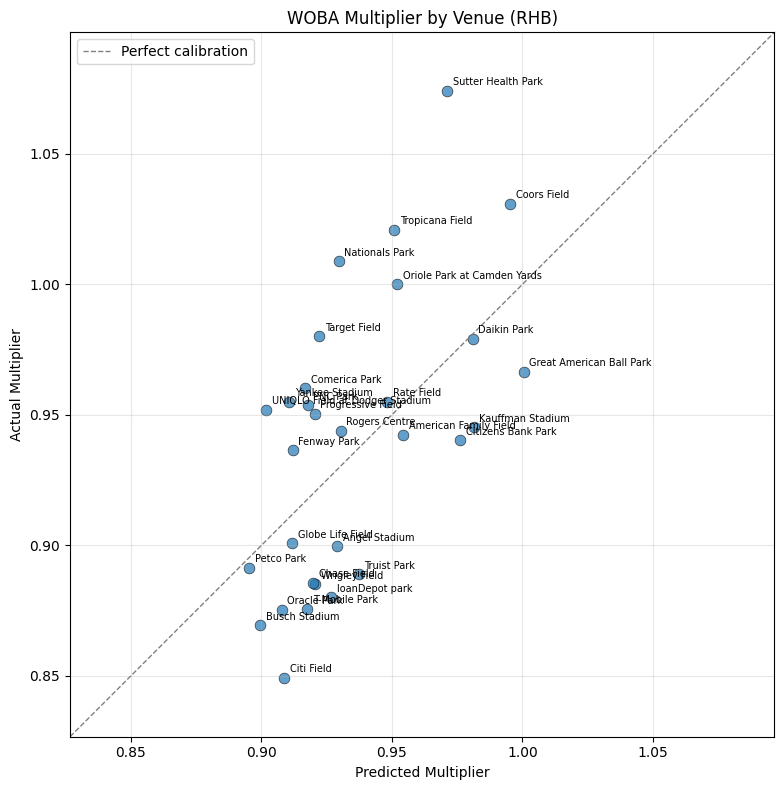

In [53]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(venue_stat_comparison['predicted_multiplier'], venue_stat_comparison['actual_multiplier'],
           s=60, alpha=0.7, edgecolor='black', linewidth=0.5)

for _, row in venue_stat_comparison.iterrows():
    ax.annotate(row['venue_name'], (row['predicted_multiplier'], row['actual_multiplier']),
                fontsize=7, xytext=(4, 4), textcoords='offset points')

lo = min(venue_stat_comparison['predicted_multiplier'].min(), venue_stat_comparison['actual_multiplier'].min())
hi = max(venue_stat_comparison['predicted_multiplier'].max(), venue_stat_comparison['actual_multiplier'].max())
pad = (hi - lo) * 0.1
lo, hi = lo - pad, hi + pad

ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=1, label='Perfect calibration')

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal', adjustable='box')

ax.set_xlabel('Predicted Multiplier')
ax.set_ylabel('Actual Multiplier')
ax.set_title(f'{stat.upper()} Multiplier by Venue ({batSide}HB)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##### Weather comparison using SIMULATED wOBA (isolates weather/venue effect)

In [57]:
test_game_mask = (weather_dataset['_date_str'] >= min_testing_date) & (weather_dataset['_date_str'] <= max_testing_date)

##### Build game_weather (weather-only lookup table, one row per test game)

In [58]:
weather_cols = ['temperature_2m', 'dew_point_2m', 'surface_pressure',
                'wind_push', 'wind_cross', 'rolling_carry_365d']

game_weather = (
    weather_dataset[test_game_mask]
    .drop_duplicates(subset='gamePk')
    [['gamePk'] + weather_cols]
)

In [59]:
top_n = 100

sim_df['wOBA_sim_combined'] = (sim_df['L_wOBA_sim'] + sim_df['R_wOBA_sim']) / 2

sim_weather_ranked = sim_df.merge(game_weather, on='gamePk', how='inner')
sim_weather_ranked = sim_weather_ranked.sort_values('wOBA_sim_combined', ascending=False)

top_sim = sim_weather_ranked.head(top_n)
bottom_sim = sim_weather_ranked.tail(top_n)

sim_summary = pd.DataFrame({
    f'Top {top_n} (by simulated wOBA)': top_sim[weather_cols].mean(),
    'Overall Average': sim_weather_ranked[weather_cols].mean(),
    f'Bottom {top_n} (by simulated wOBA)': bottom_sim[weather_cols].mean(),
}).T

sim_summary['avg_wOBA_sim'] = [
    top_sim['wOBA_sim_combined'].mean(),
    sim_weather_ranked['wOBA_sim_combined'].mean(),
    bottom_sim['wOBA_sim_combined'].mean(),
]

sim_summary

,temperature_2m,dew_point_2m,surface_pressure,wind_push,wind_cross,rolling_carry_365d,avg_wOBA_sim
Top 100 (by simulated wOBA),79.782035,55.435037,967.027326,4.791110,-2.203711,400.453520,0.380897
Overall Average,69.188766,50.298256,996.551146,1.110028,-0.152664,400.257033,0.346402
Bottom 100 (by simulated wOBA),51.517238,31.795115,1010.744599,-1.168375,1.221966,399.910519,0.317713


In [60]:
top_venue_counts = top_sim['venue_id'].map(venue_names).rename('venue_name').value_counts()
bottom_venue_counts = bottom_sim['venue_id'].map(venue_names).rename('venue_name').value_counts()


venue_count_summary = pd.concat([
    top_venue_counts.head(5).rename('count').reset_index().assign(group=f'Top 5'),
    bottom_venue_counts.head(5).rename('count').reset_index().assign(group=f'Bottom 5')
], ignore_index=True).rename(columns={'index': 'venue_name'})

venue_count_summary

,venue_name,count,group
0,Great American Ball Park,20,Top 5
1,Coors Field,19,Top 5
2,Citizens Bank Park,16,Top 5
3,Kauffman Stadium,14,Top 5
4,Sutter Health Park,9,Top 5
5,Wrigley Field,14,Bottom 5
6,Fenway Park,14,Bottom 5
7,Citi Field,12,Bottom 5
8,Busch Stadium,12,Bottom 5
9,PNC Park,7,Bottom 5


### Save

##### Folder

In [61]:
save_folder = os.path.join(model_path, "M01. Park and Weather Factors", todaysdate)
os.makedirs(save_folder, exist_ok=True)
print(f"Saving to: {save_folder}")

Saving to: C:\Users\James\Documents\MLB\Models\M01. Park and Weather Factors\20260722


##### Distance model + preprocessing

In [62]:
torch.save(best_model.state_dict(), os.path.join(save_folder, "distance_model.pt"))
joblib.dump(scaler, os.path.join(save_folder, "distance_scaler.pkl"))

distance_meta = {
    'features_cont': features_cont,
    'hidden_dims': distance_configs[best_key[0]][0],
    'dropout': distance_configs[best_key[0]][4],
    'n_venues': n_venues,
    'venue_categories': list(venue_cat_dtype.categories),
}
with open(os.path.join(save_folder, "distance_meta.json"), 'w') as f:
    json.dump(distance_meta, f)

##### Events model + preprocessing

In [63]:
torch.save(events_best_model.state_dict(), os.path.join(save_folder, "events_model.pt"))
joblib.dump(events_scaler, os.path.join(save_folder, "events_scaler.pkl"))

events_meta = {
    'features_cont': events_features_cont,
    'hidden_dims': events_configs[events_best_key[0]][0],
    'dropout': events_configs[events_best_key[0]][4],
    'n_venues': events_n_venues,
    'n_classes': events_n_classes,
    'venue_categories': list(events_venue_cat_dtype.categories),
    'classes': events_classes,
}
with open(os.path.join(save_folder, "events_meta.json"), 'w') as f:
    json.dump(events_meta, f)

##### Neutral sample (baselines + rolling carry recomputed on import)

In [64]:
sim_sample.to_csv(os.path.join(baseball_path, "Weather Sample.csv"), index=False)
print(f"Saved sample: {len(sim_sample):,} rows")

Saved sample: 50,000 rows


##### Multipliers (full history)

In [65]:
for cls in events_classes:
    history_sim_df[f'{cls}_wfx_unadj_l'] = (history_sim_df[f'L_{cls}_sim'] * n_sample_L) / baseline_counts_L[cls]
    history_sim_df[f'{cls}_wfx_unadj_r'] = (history_sim_df[f'R_{cls}_sim'] * n_sample_R) / baseline_counts_R[cls]

history_sim_df['woba_wfx_unadj_l'] = history_sim_df['L_wOBA_sim'] / baseline_rates_L['wOBA']
history_sim_df['woba_wfx_unadj_r'] = history_sim_df['R_wOBA_sim'] / baseline_rates_R['wOBA']

history_multipliers = history_sim_df.merge(
    all_games[['gamePk', 'temperature_2m', 'dew_point_2m', 'surface_pressure', 'meteo_x_vect', 'meteo_y_vect', 'rolling_carry_365d']],
    on='gamePk'
)[['gamePk', 'date', 'venue_id', 'temperature_2m', 'dew_point_2m', 'surface_pressure', 'meteo_x_vect', 'meteo_y_vect', 'rolling_carry_365d']
  + [c for c in history_sim_df.columns if 'wfx' in c]]

history_multipliers['venue_name'] = history_multipliers['venue_id'].map(venue_names)

history_multipliers.head()

,gamePk,date,venue_id,temperature_2m,dew_point_2m,surface_pressure,meteo_x_vect,meteo_y_vect,rolling_carry_365d,b1_wfx_unadj_l,b1_wfx_unadj_r,b2_wfx_unadj_l,b2_wfx_unadj_r,b3_wfx_unadj_l,b3_wfx_unadj_r,fo_wfx_unadj_l,fo_wfx_unadj_r,go_wfx_unadj_l,go_wfx_unadj_r,hr_wfx_unadj_l,hr_wfx_unadj_r,lo_wfx_unadj_l,lo_wfx_unadj_r,po_wfx_unadj_l,po_wfx_unadj_r,woba_wfx_unadj_l,woba_wfx_unadj_r,venue_name
0,413664,2015-04-07,680,52.883600,41.633600,1009.409550,2.657117,-1.716993,392.333333,1.074918,1.055385,0.729291,0.738786,0.510021,0.702742,1.131205,1.116053,0.977908,1.005556,0.554732,0.500503,1.092770,1.067732,1.011328,0.998275,0.845135,0.836986,T-Mobile Park
1,413665,2015-04-07,4169,70.000000,57.000000,1019.583440,0.000000,0.000000,392.333333,1.086359,1.098437,0.737623,0.743919,0.796234,1.044696,1.105563,1.104013,1.002716,1.008414,0.406294,0.341182,1.064409,1.041273,1.022974,1.000719,0.824346,0.824951,loanDepot park
2,413666,2015-04-07,12,70.000000,57.000000,1018.132700,0.000000,0.000000,392.333333,1.059942,1.048324,0.790165,0.767149,0.746423,0.923510,1.082972,1.089708,0.978444,0.999450,0.636464,0.569828,1.108680,1.082539,1.033464,1.018719,0.880679,0.861372,Tropicana Field
3,413667,2015-04-07,32,70.000000,57.000000,995.969100,0.000000,0.000000,392.333333,1.033040,1.041208,0.776709,0.784046,0.686143,0.908907,1.111964,1.094296,0.997252,1.016635,0.658860,0.577739,1.086151,1.052469,0.962149,0.954735,0.868258,0.863254,American Family Field
4,413668,2015-04-07,22,53.276000,50.216000,995.647340,0.662372,6.296401,392.333333,1.043417,1.038706,0.696796,0.682010,0.666805,0.761984,1.124066,1.115018,1.018332,1.037310,0.507578,0.463758,1.093026,1.080479,0.964039,0.949445,0.816191,0.807696,UNIQLO Field at Dodger Stadium


In [66]:
history_multipliers['date'] = history_multipliers['date'].astype(str).str.replace('-', '')

In [67]:
history_multipliers.to_csv(os.path.join(baseball_path, "Park and Weather Factors (New).csv"), index=False)
print(f"Saved {len(history_multipliers):,} rows to Park and Weather Factors (New).csv")

Saved 25,833 rows to Park and Weather Factors (New).csv


##### Daily Files

In [68]:
for date in history_multipliers['date'].unique():
    history_multipliers[history_multipliers['date'] == date].reset_index().to_csv(os.path.join(baseball_path, "B02. WFX", f"Park and Weather Factors {date}.csv"), index=False)